In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore",category=UserWarning,module="sklearn")


In [3]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
raw_df= pd.read_parquet("/Users/anish/Documents/Credit Card Fraud Detection/Notebooks/merged_transactions.parquet")

In [5]:
raw_df.copy()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [7]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [9]:
df=raw_df.copy()
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])
df['dob']=pd.to_datetime(df['dob'])
df['age'] = (
        pd.to_datetime(df['unix_time'], unit='s').dt.year -
        pd.to_datetime(df['dob']).dt.year
    )
df["merchant"] = df["merchant"].str.removeprefix("fraud_")


In [10]:
df = df.sort_values('trans_date_trans_time')
split_idx=int(len(df)*0.8)
train_df=df[:split_idx]
test_df=df[split_idx:]


In [11]:

def run_model(train_df,test_df,features,num_cols,cat_cols):
    
    num_pipeline=Pipeline(steps=[
    ("scaler",StandardScaler())])

    cat_pipeline=Pipeline(steps=[
    ("onehot",OneHotEncoder(handle_unknown="ignore"))])

    column_transformer=ColumnTransformer(
          transformers=[
            ("num_features",num_pipeline,num_cols),
            ("cat_features",cat_pipeline,cat_cols)
    ],
    remainder='passthrough'
          )
    preprocessor=Pipeline(steps=[
    ("column_transformer",column_transformer)
   ])
    x_train=train_df[features]
    y_train=train_df['is_fraud']

    x_test=test_df[features]
    y_test=test_df['is_fraud']

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    model= LGBMClassifier(
                     n_estimators=300,
                     num_leaves=31,
                     learning_rate=0.05,
                     scale_pos_weight=scale_pos_weight,
                     random_state=42
                    )
    train_transform=preprocessor.fit_transform(x_train)
    test_transform=preprocessor.transform(x_test)

    model.fit(train_transform, y_train)
    probs = model.predict_proba(test_transform)[:, 1]

    roc_auc=roc_auc_score(y_test,probs)
    avg_precison = average_precision_score(y_test, probs)
    preds=np.where(probs>=0.5,1,0)

    results=x_test[['cc_num']].copy()
    results['prob']=preds
    results['actual']=y_test.values
    results['roc_auc']=roc_auc
    results['avg_precision']=avg_precison
    
    ohe_feature_names = preprocessor.named_steps['column_transformer'] \
                                .named_transformers_['cat_features'] \
                                .get_feature_names_out(cat_cols).tolist()

    all_feature_names = num_cols+ohe_feature_names

    importance = pd.DataFrame({
            'feature':    all_feature_names,
            'importance': model.feature_importances_
      }).sort_values('importance', ascending=False)
    
    return results,importance,model,preprocessor

In [9]:
df= raw_df[raw_df['street'] == '44259 Beth Station Suite 215']

In [10]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


In [65]:
def calculate_metrcis(metrics,test_desc:str,result:pd.DataFrame,roc_auc:float,average_precision:float)->pd.DataFrame:
  total=len(result)
  true_positive=np.sum((result['prob']==1)&(result['actual']==1))
  false_positive=np.sum((result['prob']==1)&(result['actual']==0))
  false_negative=np.sum((result['prob']==0)&(result['actual']==1))
  true_negative=np.sum((result['prob']==0)&( result['actual']==0))

  precision=true_positive/(true_positive+false_positive)
  recall=true_positive/(true_positive+false_negative)
  f1_score=(2*precision*recall)/(precision+recall)
  f2_score=(5*precision*recall)/(4*precision+recall)
  fraud_caught_pct=(true_positive/(true_positive+false_negative))*100
  fraud_missed=(false_negative/(true_positive+false_negative))*100
  flagged=((true_positive+false_positive)/total)*100

  new_series=pd.Series({
    'ro-auc':round(roc_auc,2),
    'average_precision':round(average_precision,2),
    'precision':    round(precision, 4),
    'recall':       round(recall, 4),
    'f1_score':     round(f1_score, 4),
    'f2_score':     round(f2_score, 4),
    'Fraud Caught %': round(fraud_caught_pct, 2),
    'Fraud Missed %': round(fraud_missed, 2),
    'Flagged':      round(flagged, 2)
  }).rename(test_desc).to_frame()
  return pd.concat([metrics,new_series],axis=1)
  


In [66]:
num_cols = ['cc_num', 'amt', 'zip', 'lat', 'long',
    'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'age']

cat_cols = ['merchant', 'category', 'gender', 'first',
    'last', 'street', 'city', 'state', 'job' ]

features=num_cols+cat_cols

results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)

metrics=pd.DataFrame()
metrics=calculate_metrcis(metrics,'baseline',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10081
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 3865
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [67]:
def add_time_features(df)->pd.DataFrame: 
   df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
   df['hour_of_day'] = df['trans_date_trans_time'].dt.hour
   df['day_of_week']=df['trans_date_trans_time'].dt.day_of_week
   df['month'] = df['trans_date_trans_time'].dt.month
   df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
  
   return df

def add_velocity_features(train_df:pd.DataFrame,test_df:pd.DataFrame)->pd.DataFrame:
       train_df=train_df.copy()
       test_df=test_df.copy()
       
       train_df['_split']='train'
       test_df['_split']='test'

       df=pd.concat([train_df,test_df])
       df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
       df=df.set_index('trans_date_trans_time')
       
       for window, col in [('1h', 'txn_count_1h'), ('6h', 'txn_count_6h'), ('24h', 'txn_count_24h')]:
         df[col] = (
        df.groupby('cc_num')['amt']   
        .rolling(window)             
        .count()
        .reset_index(level=0, drop=True)
        )

       df = df.reset_index()
       
       train_df=df[df['_split']=='train'].drop(columns='_split')
       test_df=df[df['_split']=='test'].drop(columns="_split")

       return train_df,test_df
def add_fraud_rate(train_df,test_df)->pd.DataFrame:
       
       train_df = train_df.copy()
       test_df  = test_df.copy()

       global_fraud_rate=train_df['is_fraud'].mean()
       hour_fraud_rate=train_df.groupby('hour_of_day')['is_fraud'].mean()
       day_fraud_rate=train_df.groupby('day_of_week')['is_fraud'].mean()
       month_fraud_rate=train_df.groupby('month')['is_fraud'].mean()

       for data_split in[train_df,test_df]:
         data_split['hour_fraud_rate']=data_split['hour_of_day'].map(hour_fraud_rate).fillna(global_fraud_rate)
         data_split['day_fraud_rate']=data_split['day_of_week'].map(day_fraud_rate).fillna(global_fraud_rate)
         data_split['month_fraud_rate']=data_split['month'].map(month_fraud_rate).fillna(global_fraud_rate)
       return train_df,test_df

In [68]:
train_df=add_time_features(train_df)
test_df=add_time_features(test_df)
train_df,test_df=add_velocity_features(train_df,test_df)
train_df,test_df=add_fraud_rate(train_df,test_df)

/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/4207656275.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/4207656275.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour_of_day'] = df['trans_date_trans_time'].dt.hour
/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/4207656275.py:4: SettingWithCopyWarning: 
A value is trying t

In [69]:
baseline_num_cols = ['cc_num', 'amt', 'zip', 'lat', 'long',
    'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'age']

baseline_cat_cols = ['merchant', 'category', 'gender', 'first',
    'last', 'street', 'city', 'state', 'job' ]
time_based_numerical_cols=['hour_of_day', 'month', 'day_of_week',
       'is_weekend', 'txn_count_1h', 'txn_count_6h', 'txn_count_24h',
       'hour_fraud_rate', 'day_fraud_rate', 'month_fraud_rate'
]
time_based_cat_cols=[

]
num_cols=baseline_num_cols+time_based_numerical_cols
cat_cols=baseline_cat_cols+time_based_cat_cols

features=num_cols+cat_cols

results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)
metrics=calculate_metrcis(metrics,'Time based',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.431433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10286
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 3900
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


### Distance Based Features

In [70]:
def haversine_miles(df):
 R = 6371
 lat1=np.radians(df['lat'])
 lon1=np.radians(df['long'])
 lat2=np.radians(df['merch_lat'])
 lon2=np.radians(df['merch_long'])

 dlat=lat2-lat1
 dlong=lon2-lon1

 a=np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlong/2)**2
 d=2*np.arcsin(np.sqrt(a))
 return 6371*d

def add_geo_features(train_df: pd.DataFrame, test_df: pd.DataFrame) ->pd.DataFrame:
 
 train_df=train_df.copy()
 test_df=test_df.copy()

 train_df['_split']='train'
 test_df['_split']='test'

 for df in [train_df, test_df]:
        df['home_to_merchant_dist'] = haversine_miles(df)
        df['likely_diff_state'] = (df['home_to_merchant_dist'] > 200)

 df=pd.concat([train_df,test_df])

 df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

 df['prev_distance']=df.groupby('cc_num')['home_to_merchant_dist'].shift(1)
 df['dist_change_prev_txn']=np.abs(df['home_to_merchant_dist'] - df['prev_distance']).fillna(0)
 df.drop(columns=['prev_distance'],inplace=True)

 df['prev_trans_date_trans_time']=df.groupby('cc_num')['trans_date_trans_time'].shift(1)
 df['time_since_prev_txn'] = np.abs(
    (df['trans_date_trans_time'] - df['prev_trans_date_trans_time']).dt.total_seconds()
 ).fillna(0)
 df.drop(columns=['prev_trans_date_trans_time'],inplace=True)

 train_df=df[df['_split']=='train'].drop(columns=['_split'])
 test_df=df[df['_split']=='test'].drop(columns=['_split'])

 return train_df,test_df


In [71]:
train_df,test_df=add_geo_features(train_df,test_df)

In [72]:
baseline_num_cols = ['cc_num', 'amt', 'zip', 'lat', 'long',
    'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'age']

baseline_cat_cols = ['merchant', 'category', 'gender', 'first',
    'last', 'street', 'city', 'state', 'job' ]
dist_based_numerical_cols=['home_to_merchant_dist', 'likely_diff_state', 'dist_change_prev_txn',
       'time_since_prev_txn'
]
time_based_cat_cols=[

]
num_cols=baseline_num_cols+dist_based_numerical_cols
cat_cols=baseline_cat_cols+time_based_cat_cols

features=num_cols+cat_cols

results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)
metrics=calculate_metrcis(metrics,'Distance based',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10899
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 3893
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [73]:
metrics

,baseline,Time based,Distance based
ro-auc,0.9800,0.9900,0.9900
average_precision,0.4600,0.8400,0.5800
precision,0.1581,0.2662,0.1763
recall,0.7746,0.9370,0.8043
f1_score,0.2627,0.4146,0.2892
f2_score,0.4353,0.6230,0.4697
Fraud Caught %,77.4600,93.7000,80.4300
Fraud Missed %,22.5400,6.3000,19.5700
Flagged,1.7800,1.2800,1.6600


In [15]:
def add_transaction_featues(train_df,test_df):
    
    train_df=train_df.copy()
    test_df=test_df.copy()

    cardholder_stats=train_df.groupby('cc_num')['amt'].agg(['mean','std']).rename(
    columns={'mean':"amt_mean","std":'amt_std'}
     )
    for data_split in train_df,test_df:
     merged=data_split.join(cardholder_stats,on='cc_num')
     data_split['amt_z_score']=((data_split['amt']-merged['amt_mean'])/merged['amt_std']).fillna(0)

    category_stats = train_df.groupby('category')['amt'].agg(['mean', 'std']).rename(
        columns={'mean': 'cat_amt_mean', 'std': 'cat_amt_std'}
    )

    for df_split in [train_df, test_df]:
        merged = df_split.join(category_stats, on='category')
        df_split['amt_zscore_category'] = (
            (merged['amt'] - merged['cat_amt_mean']) / merged['cat_amt_std']
        ).fillna(0)
    
    for df_split in [train_df, test_df]:
      df_split['is_round_1']=(df_split['amt']%1==0).astype(int)
      df_split['is_round_10']=(df_split['amt']%10==0).astype(int)
    # return train_df,test_df
    return cardholder_stats


In [17]:
# train_df,test_df=add_transaction_featues(train_df,test_df)
cardholder_s=add_transaction_featues(train_df,test_df)

In [18]:
cardholder_s

,amt_mean,amt_std
cc_num,,
60416207185,55.988449,120.675292
60422928733,67.407852,97.437374
60423098130,105.971359,1113.039255
60427851591,108.810611,136.820255
60487002085,58.575615,138.480996
...,...,...
4958589671582726883,65.734900,143.065143
4973530368125489546,75.716212,281.973516
4980323467523543940,73.529713,127.350175


In [76]:
baseline_num_cols = ['cc_num', 'amt', 'zip', 'lat', 'long',
    'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'age']

baseline_cat_cols = ['merchant', 'category', 'gender', 'first',
    'last', 'street', 'city', 'state', 'job' ]
transaction_based_numerical_cols=['amt_z_score', 'amt_zscore_category',
       'is_round_1', 'is_round_10'
]
transaction_based_cat_cols=[

]
num_cols=baseline_num_cols+transaction_based_cat_cols
cat_cols=baseline_cat_cols+transaction_based_cat_cols

features=num_cols+cat_cols

results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)
metrics=calculate_metrcis(metrics,'Transaction based',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10134
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 3890
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [77]:
def add_merchant_based_features(train_df,test_df):
     
      train_df = train_df.copy()
      test_df  = test_df.copy()

      global_fraud_rate = train_df['is_fraud'].mean()
   
      merchant_fraud_rate = (
        train_df.groupby('merchant')['is_fraud']
        .mean()
        .rename('merchant_fraud_rate')
      )*100

      for df_split in [train_df, test_df]:
        df_split['merchant_fraud_rate'] = (
            df_split['merchant']
            .map(merchant_fraud_rate)
            .fillna(global_fraud_rate)  
        )

      category_fraud_rate = (
        train_df.groupby('category')['is_fraud']
        .mean()
        .rename('category_fraud_rate')
      )*100

      for df_split in [train_df, test_df]:
        df_split['category_fraud_rate'] = (
            df_split['category']
            .map(category_fraud_rate)
            .fillna(global_fraud_rate)  
      ) 
        
      cardholder_merchant_counts= train_df.groupby(['cc_num', 'merchant'])\
                                          .size()\
                                          .rename('cc_merchant_txn_count')
      

      for data_split in [train_df,test_df]:
       data_split['cc_merchant_txn_count']=(data_split.set_index(['cc_num','merchant'])
                                            .index
                                            .map(cardholder_merchant_counts)
                                            .fillna(0)
                                            .values
                                            )
      
      return train_df,test_df
    

In [78]:
train_df,test_df=add_merchant_based_features(train_df,test_df)

In [79]:
baseline_num_cols = ['cc_num', 'amt', 'zip', 'lat', 'long',
    'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'age']

baseline_cat_cols = ['merchant', 'category', 'gender', 'first',
    'last', 'street', 'city', 'state', 'job' ]
merchant_based_numerical_cols=['merchant_fraud_rate',
       'category_fraud_rate', 'cc_merchant_txn_count'
]
merchant_based_cat_cols=[

]
num_cols=baseline_num_cols+merchant_based_numerical_cols
cat_cols=baseline_cat_cols+merchant_based_cat_cols

features=num_cols+cat_cols

results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)

metrics=calculate_metrcis(metrics,'Merchant Based',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10427
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 3893
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [80]:
def cardholder_behaviour_features(train_df,test_df):
     train_df = train_df.copy()
     test_df  = test_df.copy()

     first_txn_date = (
        train_df.groupby('cc_num')['trans_date_trans_time']
        .min()
        .rename('first_txn_date')
     )

     for df_split in [train_df, test_df]:
        df_split['account_age_days'] = (
            df_split['trans_date_trans_time']
            - df_split['cc_num'].map(first_txn_date)
        ).dt.days.fillna(0)

   
     top_category = (
        train_df.groupby('cc_num')['category']
        .agg(lambda x: x.value_counts().index[0])
        .rename('top_category')
     )

     for df_split in [train_df, test_df]:
        df_split['is_typical_category'] = (
            df_split['category'] == df_split['cc_num'].map(top_category)
        ).astype(int)

   
     cardholder_txn_count = train_df.groupby('cc_num').size()

     cardholder_date_range = (
        train_df.groupby('cc_num')['trans_date_trans_time']
        .agg(lambda x: (x.max() - x.min()).days + 1) 
      )

     card_usage_freq = (
        (cardholder_txn_count / cardholder_date_range)
        .rename('card_usage_freq')
      )

     global_usage_freq = card_usage_freq.mean()

     for df_split in [train_df, test_df]:
        df_split['card_usage_freq'] = (
            df_split['cc_num']
            .map(card_usage_freq)
            .fillna(global_usage_freq)
      )
    

     category_probability = (
      train_df.groupby(['cc_num', 'category'])['amt']
       .count()
      / train_df.groupby('cc_num')['category'].count()
      ).reset_index(name='category_probability')

     category_probability['entropy_component'] = (
     category_probability['category_probability']
     * np.log2(category_probability['category_probability'])
   )

     customer_category_entropy = (
      -category_probability.groupby('cc_num')['entropy_component'].sum()
   )
     global_customer_entropy = customer_category_entropy.median()

     for data_split in [train_df, test_df]:
      data_split['customer_category_entropy'] = (
        data_split['cc_num'].map(customer_category_entropy).fillna(global_customer_entropy)
   )

     return train_df, test_df

In [81]:
train_df,test_df=cardholder_behaviour_features(train_df,test_df)

In [82]:
baseline_num_cols = ['cc_num', 'amt', 'zip', 'lat', 'long',
    'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'age']

baseline_cat_cols = ['merchant', 'category', 'gender', 'first',
    'last', 'street', 'city', 'state', 'job' ]
cardholder_based_numerical_cols=['account_age_days',
       'is_typical_category', 'card_usage_freq','customer_category_entropy'
]
cardholder_based_cat_cols=[

]
num_cols=baseline_num_cols+cardholder_based_numerical_cols
cat_cols=baseline_cat_cols+cardholder_based_cat_cols

features=num_cols+cat_cols

results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)
metrics=calculate_metrcis(metrics,'Cardholder based',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.411116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10898
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 3894
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [83]:
metrics

,baseline,Time based,Distance based,Transaction based,Merchant Based,Cardholder based
ro-auc,0.9800,0.9900,0.9900,0.9800,0.9800,0.9800
average_precision,0.4600,0.8400,0.5800,0.4900,0.4600,0.4500
precision,0.1581,0.2662,0.1763,0.1832,0.1567,0.1945
recall,0.7746,0.9370,0.8043,0.7776,0.7709,0.7079
f1_score,0.2627,0.4146,0.2892,0.2965,0.2605,0.3052
f2_score,0.4353,0.6230,0.4697,0.4716,0.4322,0.4634
Fraud Caught %,77.4600,93.7000,80.4300,77.7600,77.0900,70.7900
Fraud Missed %,22.5400,6.3000,19.5700,22.2400,22.9100,29.2100
Flagged,1.7800,1.2800,1.6600,1.5500,1.7900,1.3300


In [84]:
num_cols = [
            #Baseline
            'cc_num',
            'amt',
            'zip',
            'lat',
            'long',
            'city_pop',
            'unix_time',
            'merch_lat',
            'merch_long',
            'age',
            
            #Time based
            'hour_of_day',
            'month',
            'day_of_week',
            'is_weekend',
            'txn_count_1h', 
            'txn_count_6h',
            'txn_count_24h',
            'hour_fraud_rate',
            'day_fraud_rate',
            'month_fraud_rate',
           
        
            #Distance based

            'home_to_merchant_dist',
            'likely_diff_state',
            'dist_change_prev_txn',
            'time_since_prev_txn',

            #Transaction Based
            'amt_z_score',
            'amt_zscore_category',
            'is_round_1',
            'is_round_10',

            #Merchant Based
            # 'merchant_fraud_rate',
            # 'category_fraud_rate',
            'cc_merchant_txn_count',
            
            'account_age_days',
            'is_typical_category',
            'card_usage_freq',
            'customer_category_entropy'
            ]

cat_cols = ['merchant', 'category', 'gender', 'first',
    'last', 'street', 'city', 'state', 'job' ]

features=num_cols+cat_cols

results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)
metrics=calculate_metrcis(metrics,'All features',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.151466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12354
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 3912
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [85]:
metrics

,baseline,Time based,Distance based,Transaction based,Merchant Based,Cardholder based,All features
ro-auc,0.9800,0.9900,0.9900,0.9800,0.9800,0.9800,1.0000
average_precision,0.4600,0.8400,0.5800,0.4900,0.4600,0.4500,0.8900
precision,0.1581,0.2662,0.1763,0.1832,0.1567,0.1945,0.4031
recall,0.7746,0.9370,0.8043,0.7776,0.7709,0.7079,0.9355
f1_score,0.2627,0.4146,0.2892,0.2965,0.2605,0.3052,0.5634
f2_score,0.4353,0.6230,0.4697,0.4716,0.4322,0.4634,0.7400
Fraud Caught %,77.4600,93.7000,80.4300,77.7600,77.0900,70.7900,93.5500
Fraud Missed %,22.5400,6.3000,19.5700,22.2400,22.9100,29.2100,6.4500
Flagged,1.7800,1.2800,1.6600,1.5500,1.7900,1.3300,0.8500


/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/1887937623.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hour_fraud_rate, x="hour_of_day", y="is_fraud", palette=hour_colors, ax=ax1)
/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/1887937623.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=week_fraud_rate, x="day_of_week", y="is_fraud", palette=week_colors, ax=ax2)
/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/1887937623.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barp

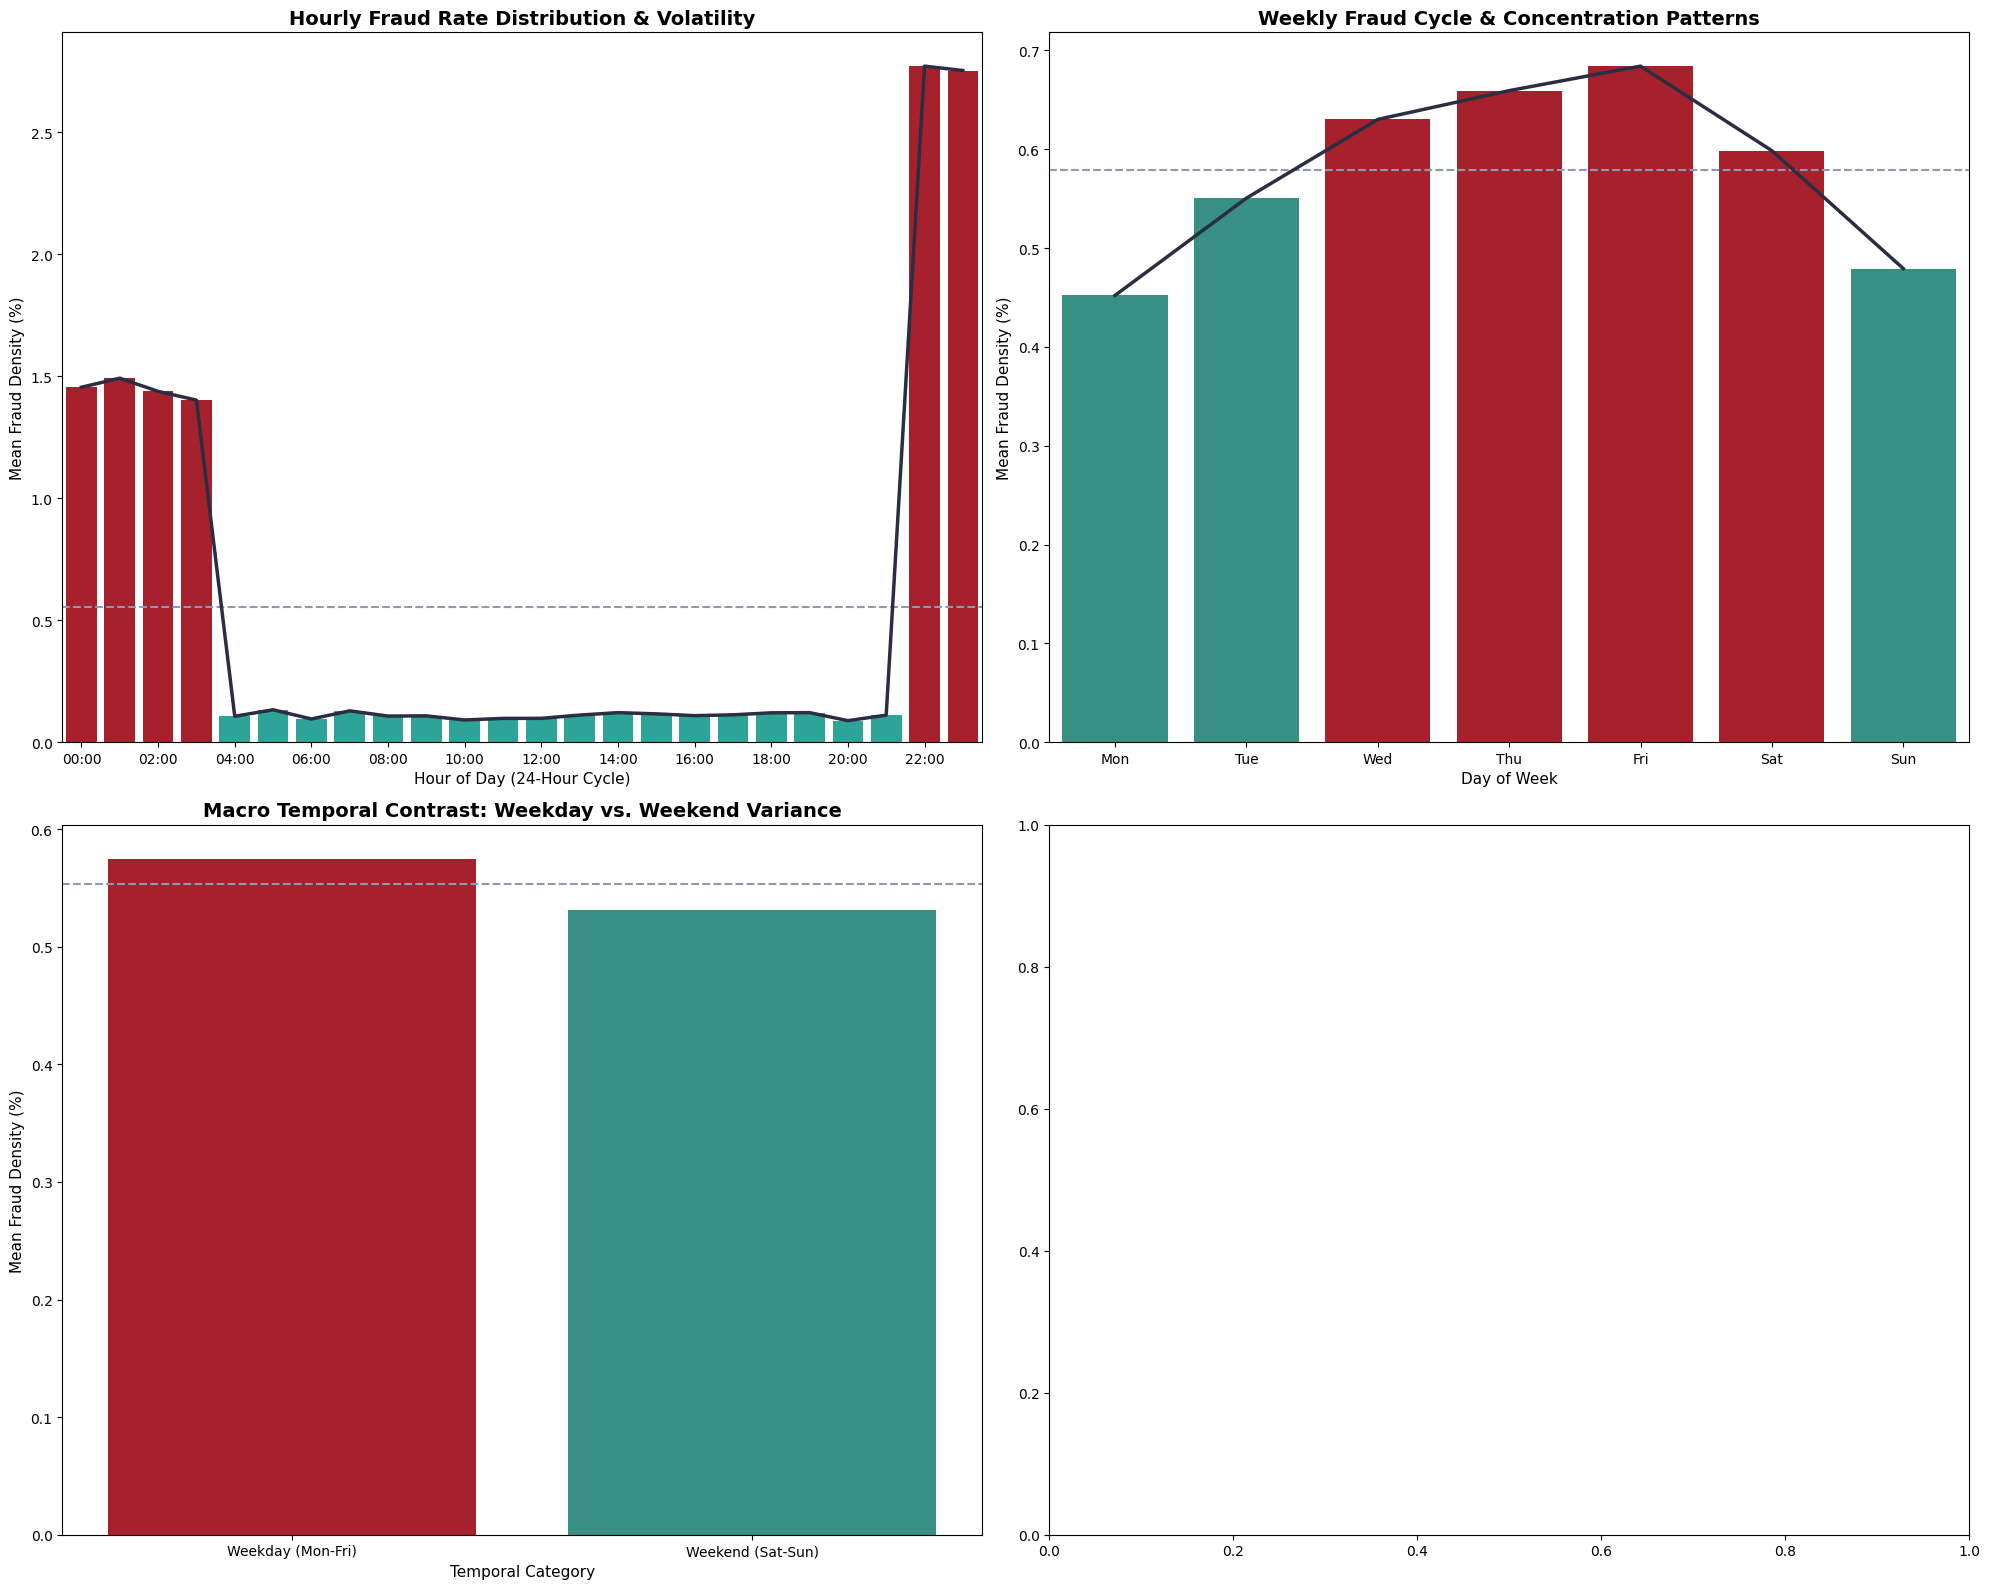

In [86]:


fig, axis = plt.subplots(2, 2, figsize=(20, 16))

ax1 = axis[0, 0]
ax2 = axis[0, 1]
ax3 = axis[1, 0]
ax4 = axis[1, 1]

hour_fraud_rate = (train_df.groupby('hour_of_day')['is_fraud'].mean() * 100).reset_index()
week_fraud_rate = (train_df.groupby('day_of_week')['is_fraud'].mean() * 100).reset_index()
weekend_fraud_rate = (train_df.groupby('is_weekend')['is_fraud'].mean() * 100).reset_index()

global_hour_avg = hour_fraud_rate['is_fraud'].mean()
global_week_avg = week_fraud_rate['is_fraud'].mean()
global_weekend_avg = weekend_fraud_rate['is_fraud'].mean()

hour_colors = ["#bc0b19" if rate > global_hour_avg else "#19b8a6" for rate in hour_fraud_rate['is_fraud']]

sns.lineplot(data=hour_fraud_rate, x="hour_of_day", y="is_fraud", ax=ax1, color='#2b2d42', linewidth=2.5, zorder=3)
sns.barplot(data=hour_fraud_rate, x="hour_of_day", y="is_fraud", palette=hour_colors, ax=ax1)

ax1.set_title("Hourly Fraud Rate Distribution & Volatility", fontsize=14, fontweight='bold')
ax1.set_xlabel("Hour of Day (24-Hour Cycle)", fontsize=11)
ax1.set_ylabel("Mean Fraud Density (%)", fontsize=11)
ax1.axhline(y=global_hour_avg, color='#8d99ae', linestyle='--', linewidth=1.5)
ax1.set_xticks(range(0, 24, 2))
ax1.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])

week_colors = ['#bc0b19' if rate > global_week_avg else '#2a9d8f' for rate in week_fraud_rate['is_fraud']]

sns.lineplot(data=week_fraud_rate, x="day_of_week", y="is_fraud", ax=ax2, color='#2b2d42', linewidth=2.5, zorder=3)
sns.barplot(data=week_fraud_rate, x="day_of_week", y="is_fraud", palette=week_colors, ax=ax2)

ax2.set_title("Weekly Fraud Cycle & Concentration Patterns", fontsize=14, fontweight='bold')
ax2.set_xlabel("Day of Week", fontsize=11)
ax2.set_ylabel("Mean Fraud Density (%)", fontsize=11)
ax2.axhline(y=global_week_avg, color='#8d99ae', linestyle='--', linewidth=1.5)
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

weekend_colors = ['#bc0b19' if rate > global_weekend_avg else '#2a9d8f' for rate in weekend_fraud_rate['is_fraud']]

sns.barplot(data=weekend_fraud_rate, x="is_weekend", y="is_fraud", palette=weekend_colors, ax=ax3)

ax3.set_title("Macro Temporal Contrast: Weekday vs. Weekend Variance", fontsize=14, fontweight='bold')
ax3.set_xlabel("Temporal Category", fontsize=11)
ax3.set_ylabel("Mean Fraud Density (%)", fontsize=11)
ax3.axhline(y=global_weekend_avg, color='#8d99ae', linestyle='--', linewidth=1.5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Weekday (Mon-Fri)', 'Weekend (Sat-Sun)'])

plt.tight_layout()
plt.show()

In [87]:
def flag_high_risk(df: pd.DataFrame) -> pd.DataFrame:


        df['is_low_risk_hour'] = (
            df['hour_of_day'].between(4, 21)
        ).astype(int)

        # 00:00 - 04:00
        df['is_early_morning'] = (
            df['hour_of_day'] <= 4
        ).astype(int)

        # 22:00 - 23:00
        df['is_late_night'] = (
            df['hour_of_day'].isin([22, 23])
        ).astype(int)

        df['is_high_risk_day'] = (
            df['day_of_week'].isin([2, 3, 4, 5])
        ).astype(int)

        df['is_high_risk_window'] = (
            (df['is_high_risk_day'] == 1) &
            (
                (df['is_early_morning'] == 1) |
                (df['is_late_night']    == 1)
            )
        ).astype(int)


        return df


       

In [88]:
train_df = flag_high_risk(train_df)
test_df  = flag_high_risk(test_df)


In [89]:
train_df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'age', 'hour_of_day', 'day_of_week', 'month',
       'is_weekend', 'txn_count_1h', 'txn_count_6h', 'txn_count_24h',
       'hour_fraud_rate', 'day_fraud_rate', 'month_fraud_rate',
       'home_to_merchant_dist', 'likely_diff_state', 'dist_change_prev_txn',
       'time_since_prev_txn', 'amt_z_score', 'amt_zscore_category',
       'is_round_1', 'is_round_10', 'merchant_fraud_rate',
       'category_fraud_rate', 'cc_merchant_txn_count', 'account_age_days',
       'is_typical_category', 'card_usage_freq', 'customer_category_entropy',
       'is_low_risk_hour', 'is_early_morning', 'is_late_night',
       'is_high_risk_day', 'is_high_risk_window'],
      dtype='object')

/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/2501096329.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_cities, y="city", x="fraud_rate", ax=ax2, palette=city_colors)


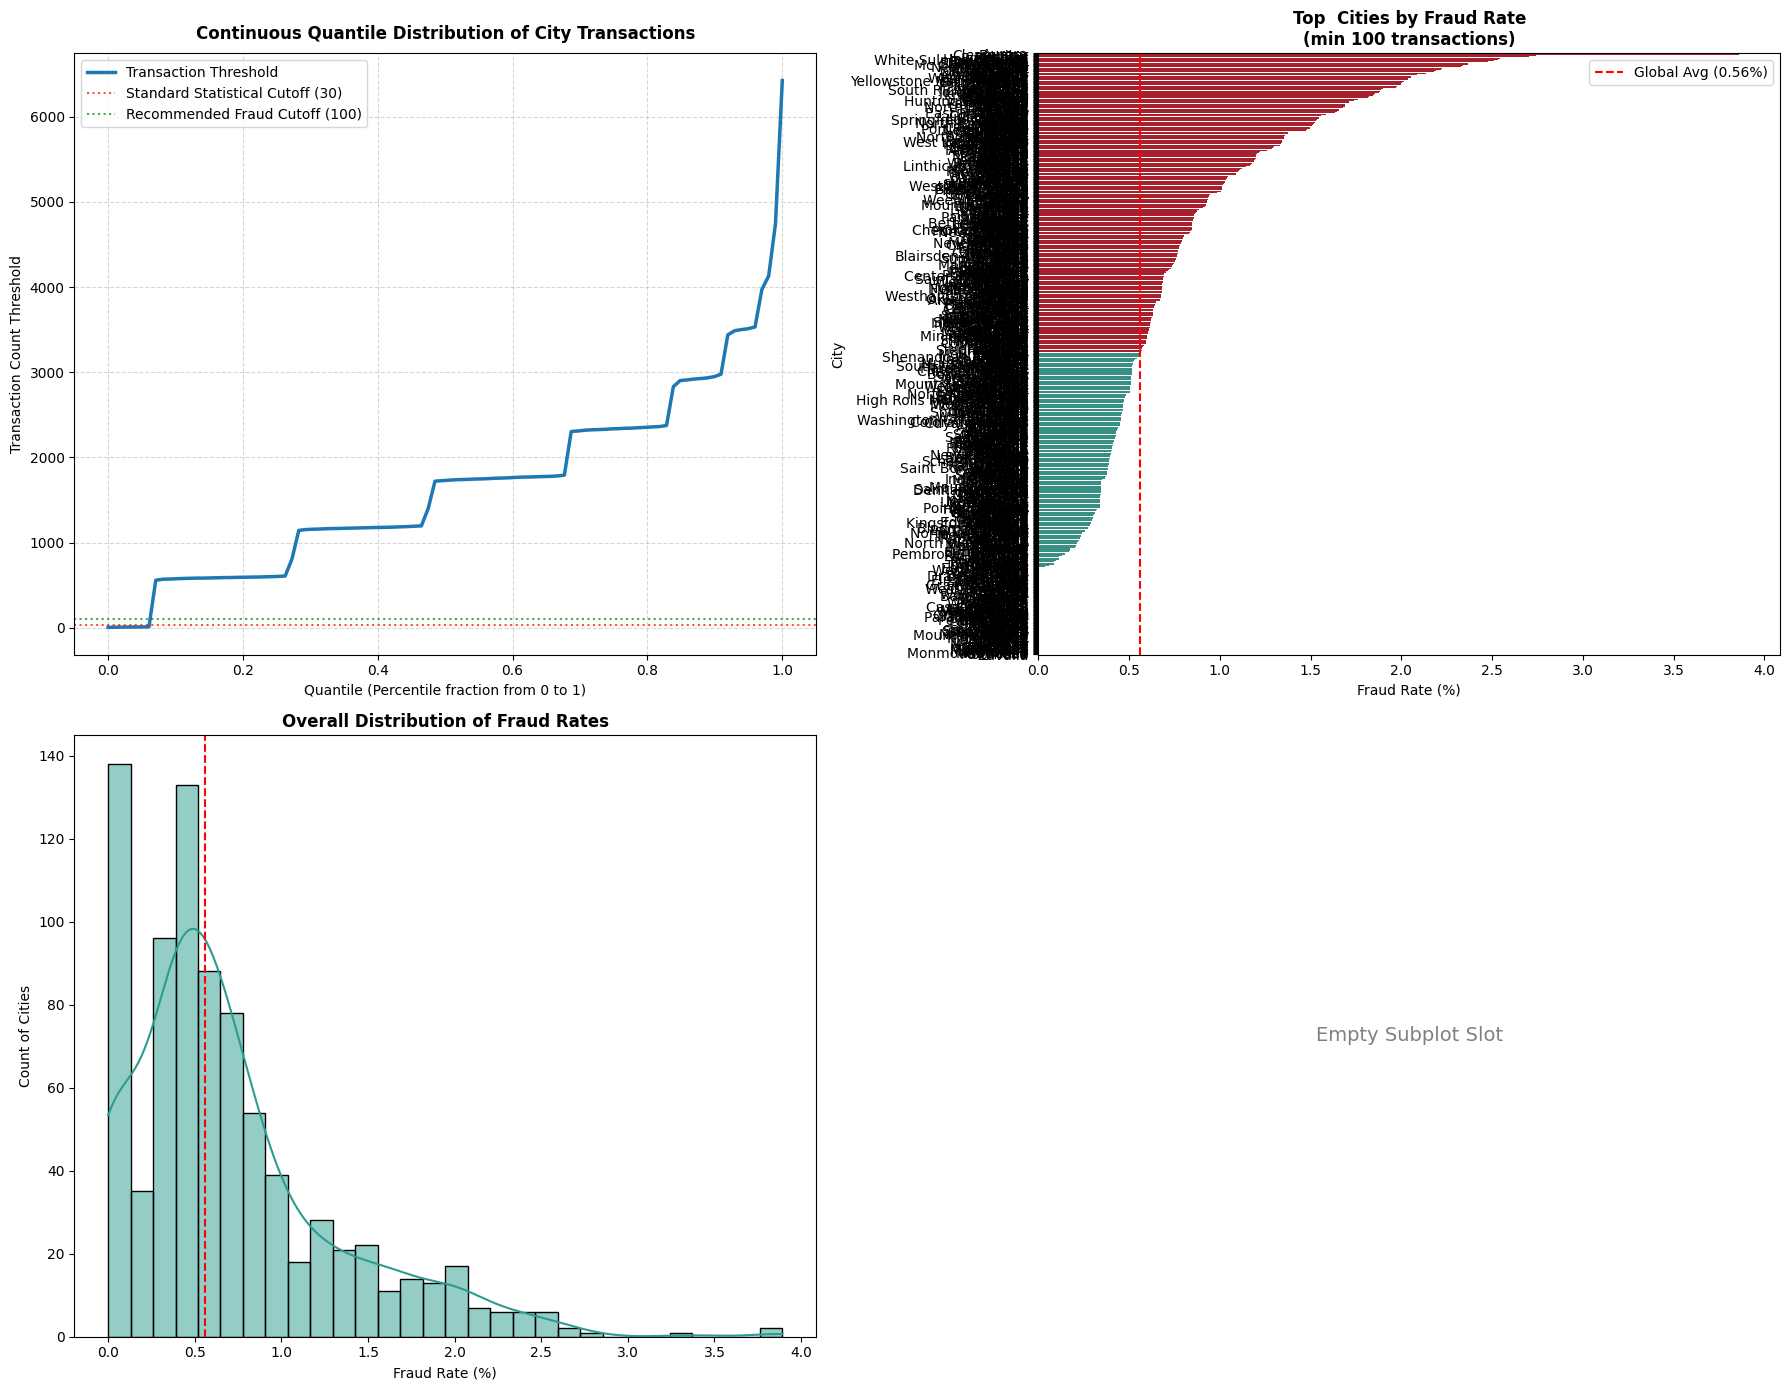

In [90]:
min_transactions=100
# 2. Process data FIRST so the arrays exist for plotting
city_fraud_rate = (train_df.groupby('city').agg(
    fraud_rate=("is_fraud", "mean"),
    total_transactions=("is_fraud", "count")
 ).reset_index())

city_fraud_rate['fraud_rate'] = city_fraud_rate['fraud_rate'] * 100
global_city_fraud_rate = train_df['is_fraud'].mean() * 100

# Calculate continuous quantiles based on the raw, unfiltered transaction counts
quantiles = np.linspace(0, 1, 100)
thresholds = [city_fraud_rate['total_transactions'].quantile(q) for q in quantiles]

# Filter and sort data for the bar plot view
filtered_cities= city_fraud_rate[city_fraud_rate["total_transactions"] >= min_transactions].sort_values(by="fraud_rate", ascending=False)
city_colors = ['#bc0b19' if rate > global_city_fraud_rate else '#2a9d8f' for rate in filtered_cities['fraud_rate']]


fig, axis = plt.subplots(2, 2, figsize=(18, 14))
ax1 = axis[0, 0]
ax2 = axis[0, 1]
ax3 = axis[1, 0]
ax4 = axis[1, 1]


# --- PLOT 1 (ax1): Continuous Quantile Line Plot ---
ax1.plot(quantiles, thresholds, color='#1f77b4', linewidth=2.5, label='Transaction Threshold')
ax1.axhline(y=30, color='red', linestyle=':', alpha=0.7, label='Standard Statistical Cutoff (30)')
ax1.axhline(y=100, color='green', linestyle=':', alpha=0.7, label='Recommended Fraud Cutoff (100)')
ax1.set_title('Continuous Quantile Distribution of City Transactions', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Quantile (Percentile fraction from 0 to 1)')
ax1.set_ylabel('Transaction Count Threshold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()


# --- PLOT 2 (ax2): Top Cities Bar Chart ---
sns.barplot(data=filtered_cities, y="city", x="fraud_rate", ax=ax2, palette=city_colors)
ax2.axvline(global_city_fraud_rate, color='red', linestyle='--', linewidth=1.5, label=f'Global Avg ({global_city_fraud_rate:.2f}%)')
ax2.set_title(f'Top  Cities by Fraud Rate\n(min {min_transactions} transactions)', fontweight='bold')
ax2.set_xlabel('Fraud Rate (%)')
ax2.set_ylabel('City')
ax2.legend()


# --- PLOT 3 (ax3): Overall Distribution Histogram ---
sns.histplot(data=filtered_cities, x='fraud_rate', bins=30, ax=ax3, color='#2a9d8f', kde=True)
ax3.axvline(global_city_fraud_rate, color='red', linestyle='--', linewidth=1.5)
ax3.set_title('Overall Distribution of Fraud Rates', fontweight='bold')
ax3.set_xlabel('Fraud Rate (%)')
ax3.set_ylabel('Count of Cities')


# --- PLOT 4 (ax4): Blank placeholder for future charts ---
ax4.text(0.5, 0.5, 'Empty Subplot Slot', fontsize=14, ha='center', va='center', color='gray')
ax4.set_axis_off()


plt.tight_layout()
plt.show()

In [91]:
def add_high_risk_city_feature(smoothing,train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple:

    train_df = train_df.copy()
    test_df  = test_df.copy()

    global_mean=train_df['is_fraud'].mean()

    city_stats=train_df.groupby('city').agg(
        count=('is_fraud','count'),
        mean=('is_fraud','mean')
    )

    city_stats['smoothed_score']=((city_stats['count']*city_stats['mean'])+(smoothing*global_mean))/(city_stats['count']+smoothing)
    city_risk_score=city_stats['smoothed_score']
    for data_split in [train_df,test_df]:
        data_split['city_fraud_risk_score']=data_split['city'].map(city_risk_score)


    return train_df,test_df

train_df,test_df=add_high_risk_city_feature(100,train_df,test_df)

/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/1612303437.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper left")


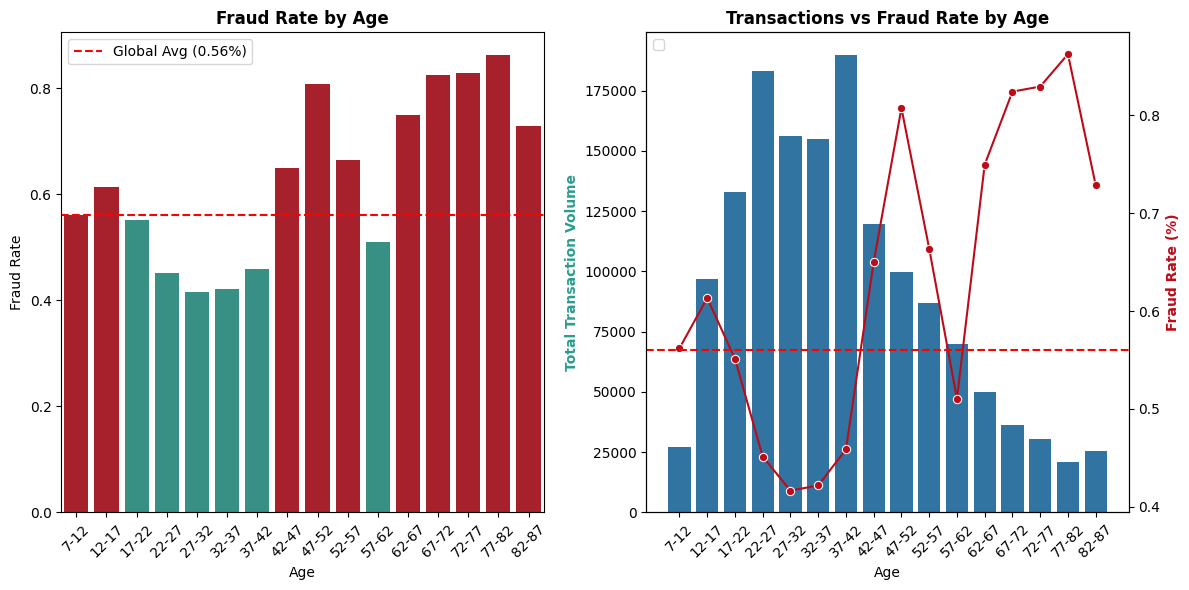

In [92]:
fig, axis = plt.subplots(1, 2, figsize=(12, 6))
ax1 = axis[0]
ax2 = axis[1]

transaction_year = pd.to_datetime(train_df['unix_time'], unit='s').dt.year.astype(int)
birth_year = pd.to_datetime(train_df['dob']).dt.year.astype(int)
train_df['age'] = (transaction_year - birth_year).astype(int)
bins= [7,12,17,22,27,32,37,42,47,52,57,62,67,72,77,82,87]
labels = [
    '7-12','12-17','17-22','22-27','27-32','32-37',
    '37-42','42-47','47-52','52-57','57-62','62-67',
    '67-72','72-77','77-82','82-87'
]
train_df['age_bins']=pd.cut(train_df['age'],bins=bins,labels=labels)
age_fraud_rate = (train_df.groupby('age_bins',observed=False)).agg(
    fraud_rate=("is_fraud", "mean"),
    total_transactions=("is_fraud", "count")
).reset_index()

age_fraud_rate['age_bins'] = age_fraud_rate['age_bins'].astype(str)
age_fraud_rate['fraud_rate'] = age_fraud_rate['fraud_rate'] * 100
global_age_fraud_rate = train_df['is_fraud'].mean() * 100

city_colors = ['#bc0b19' if rate > global_age_fraud_rate else '#2a9d8f' for rate in age_fraud_rate['fraud_rate']]

sns.barplot(data=age_fraud_rate, y="fraud_rate", x="age_bins",hue="age_bins",
 ax=ax1, palette=city_colors)
ax1.axhline(global_age_fraud_rate, color='red', linestyle='--', linewidth=1.5, label=f'Global Avg ({global_age_fraud_rate:.2f}%)')
ax1.set_title('Fraud Rate by Age', fontweight='bold')
ax1.set_xlabel('Age')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Fraud Rate')

sns.barplot(data=age_fraud_rate,
            y="total_transactions",
            x="age_bins", ax=ax2)
ax2.set_title('Transactions vs Fraud Rate by Age', fontweight='bold')
ax2.set_xlabel('Age')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel('Total Transaction Volume', color='#2a9d8f', fontweight='bold')

ax2_twin = ax2.twinx()
sns.lineplot(data=age_fraud_rate, y="fraud_rate", x="age_bins", ax=ax2_twin, color='#bc0b19', marker='o')
ax2_twin.axhline(global_age_fraud_rate, color='red', linestyle='--', linewidth=1.5)
ax2.legend(loc="upper left")
ax2_twin.set_ylabel('Fraud Rate (%)', color='#bc0b19', fontweight='bold')

plt.tight_layout()
plt.show()

In [93]:
def add_age_features(train_df:pd.DataFrame,test_df:pd.DataFrame)->pd.DataFrame:
   train_df=train_df.copy()
   test_df=test_df.copy()
   for data_split in [train_df,test_df]:
      data_split['is_high_risk_age']=(df['age']>62).astype(int)
      data_split['is_medium_risk_age']=(df['age'].between(43,61).astype(int))
      data_split['is_low_risk_age']=(df['age'].between(17,42).astype(int))
      
   return train_df,test_df

train_df,test_df=add_age_features(train_df,test_df)

/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/582348943.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_20602/582348943.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(['Legitimate', 'Fraud'])


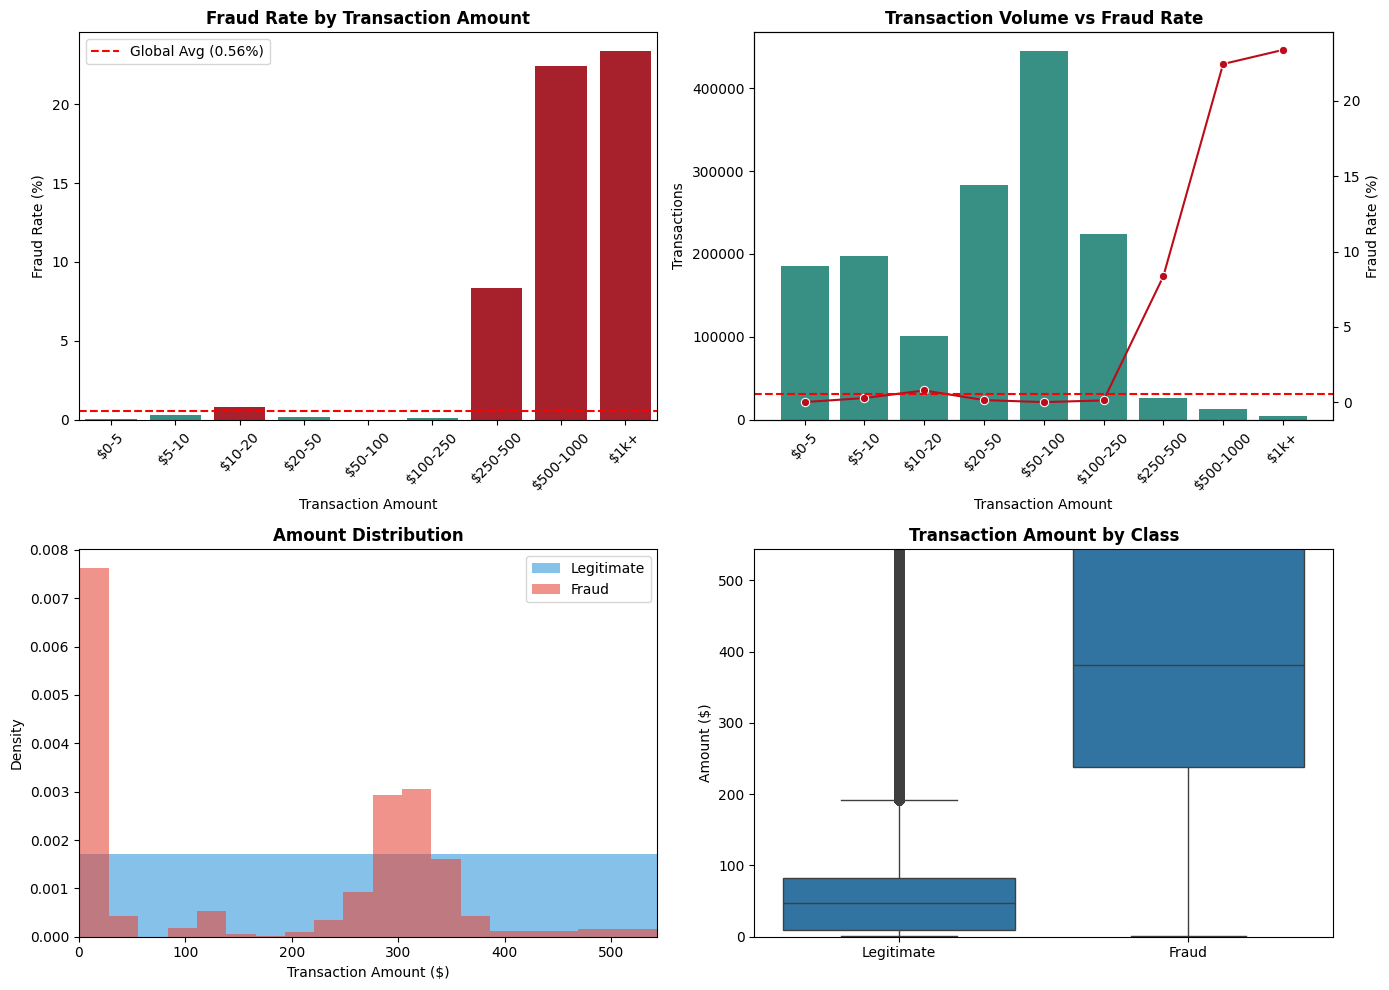

In [94]:
fig, axis = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axis[0, 0]
ax2 = axis[0, 1]
ax3 = axis[1, 0]
ax4 = axis[1, 1]

# Amount bins
amount_bins = [0, 5, 10, 20, 50, 100, 250, 500, 1000, np.inf]
amount_labels = [
    '$0-5','$5-10','$10-20','$20-50',
    '$50-100','$100-250','$250-500',
    '$500-1000','$1k+'
]

train_df['amt_bin'] = pd.cut(
    train_df['amt'],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

amt_fraud_rate = (
    train_df.groupby('amt_bin', observed=True)['is_fraud']
    .agg(
        fraud_rate='mean',
        transactions='count'
    )
    .reset_index()
)

amt_fraud_rate['fraud_rate'] *= 100
global_fraud_rate = train_df['is_fraud'].mean() * 100

colors = [
    '#bc0b19' if x > global_fraud_rate else '#2a9d8f'
    for x in amt_fraud_rate['fraud_rate']
]

sns.barplot(
    data=amt_fraud_rate,
    x='amt_bin',
    y='fraud_rate',
    palette=colors,
    ax=ax1
)

ax1.axhline(
    global_fraud_rate,
    color='red',
    linestyle='--',
    label=f'Global Avg ({global_fraud_rate:.2f}%)'
)

ax1.set_title('Fraud Rate by Transaction Amount', fontweight='bold')
ax1.set_xlabel('Transaction Amount')
ax1.set_ylabel('Fraud Rate (%)')
ax1.tick_params(axis='x', rotation=45)
ax1.legend()


sns.barplot(
    data=amt_fraud_rate,
    x='amt_bin',
    y='transactions',
    color='#2a9d8f',
    ax=ax2
)

ax2.set_title('Transaction Volume vs Fraud Rate', fontweight='bold')
ax2.set_xlabel('Transaction Amount')
ax2.set_ylabel('Transactions')
ax2.tick_params(axis='x', rotation=45)

ax2_twin = ax2.twinx()

sns.lineplot(
    data=amt_fraud_rate,
    x='amt_bin',
    y='fraud_rate',
    marker='o',
    color='#bc0b19',
    ax=ax2_twin
)

ax2_twin.axhline(
    global_fraud_rate,
    color='red',
    linestyle='--'
)

ax2_twin.set_ylabel('Fraud Rate (%)')


fraud_amt = train_df.loc[train_df['is_fraud'] == 1, 'amt']
legit_amt = train_df.loc[train_df['is_fraud'] == 0, 'amt']

ax3.hist(
    legit_amt,
    bins=50,
    density=True,
    alpha=0.6,
    color='#3498db',
    label='Legitimate'
)

ax3.hist(
    fraud_amt,
    bins=50,
    density=True,
    alpha=0.6,
    color='#e74c3c',
    label='Fraud'
)

ax3.set_xlim(0, train_df['amt'].quantile(0.99))
ax3.set_title('Amount Distribution', fontweight='bold')
ax3.set_xlabel('Transaction Amount ($)')
ax3.set_ylabel('Density')
ax3.legend()

sns.boxplot(
    data=train_df,
    x='is_fraud',
    y='amt',
    ax=ax4
)

ax4.set_ylim(0, train_df['amt'].quantile(0.99))
ax4.set_xticklabels(['Legitimate', 'Fraud'])

ax4.set_title('Transaction Amount by Class', fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

In [95]:
def add_amount_risk_features(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple:
    
    train_df = train_df.copy()
    test_df  = test_df.copy()

    for df in [train_df, test_df]:


        df['is_high_risk_amt']      = (df['amt'] >= 250).astype(int)

        df['is_very_high_risk_amt'] = (df['amt'] >= 500).astype(int)

        df['is_card_testing_amt']   = (df['amt'].between(10, 25)).astype(int)

        df['is_low_risk_amt']       = (df['amt'].between(50, 100)).astype(int)

        df['is_micro_amt']          = (df['amt'] <= 5).astype(int)

    return train_df, test_df


In [96]:
train_df,test_df =add_amount_risk_features(train_df,test_df)


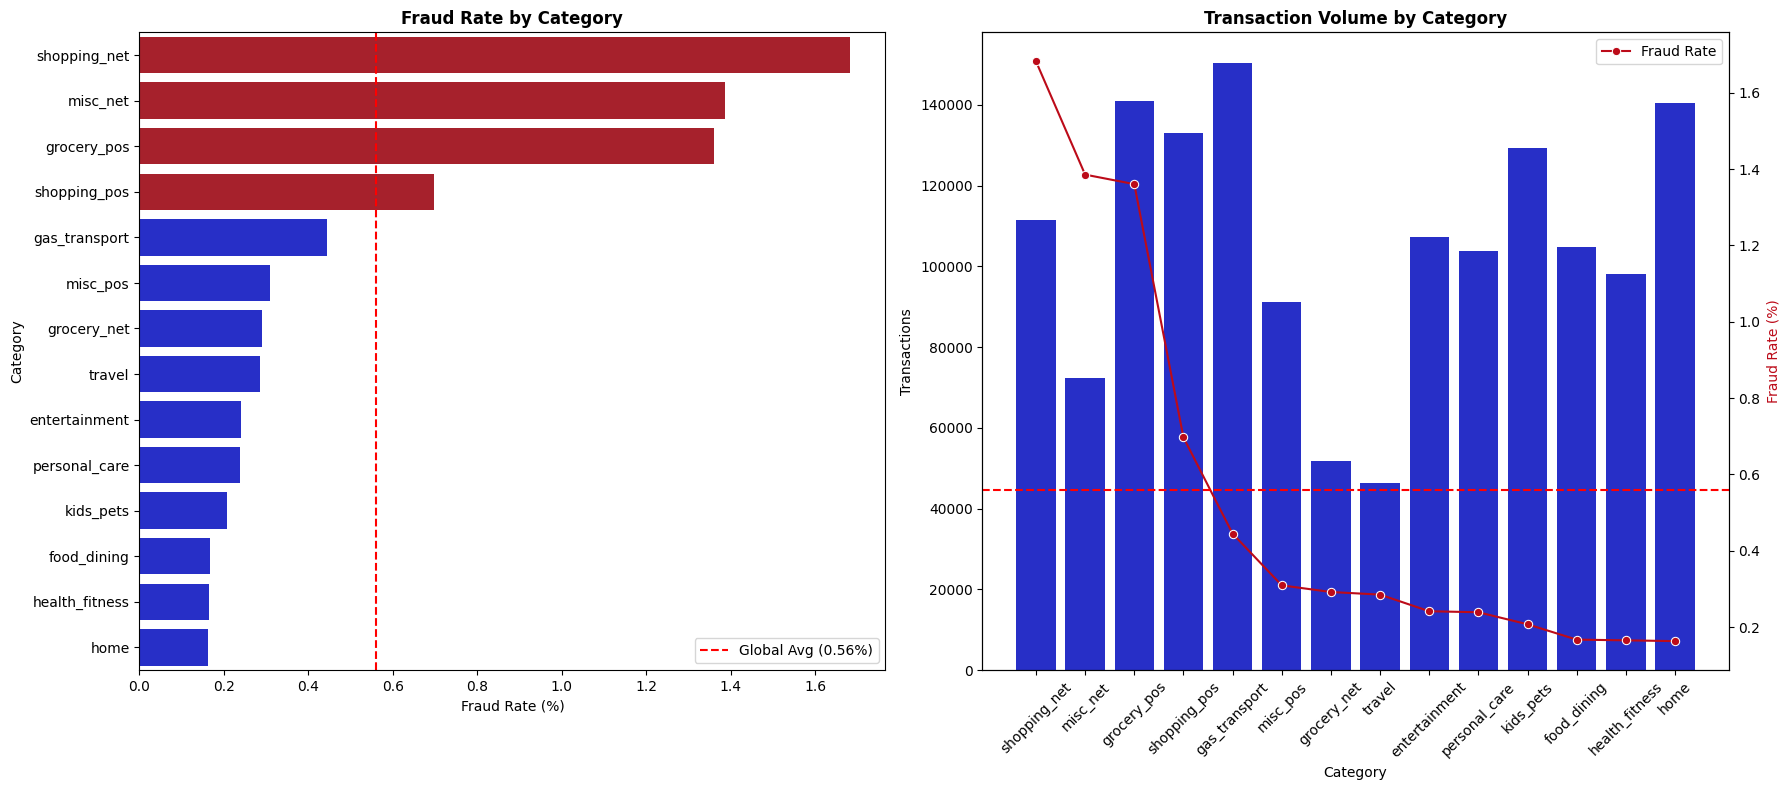

In [97]:
fig, axis = plt.subplots(1, 2, figsize=(18, 8))

ax1, ax2 = axis

cat_fraud_rate = (
    train_df.groupby("category")
    .agg(
        fraud_rate=("is_fraud", "mean"),
        total_transactions=("is_fraud", "count")
    )
    .reset_index()
)

cat_fraud_rate["fraud_rate"] *= 100

global_cat_fraud_rate = train_df["is_fraud"].mean() * 100

cat_fraud_rate = cat_fraud_rate.sort_values(
    by="fraud_rate",
    ascending=False
)

cat_colors = [
    "#bc0b19" if x > global_cat_fraud_rate else "#0c17e2"
    for x in cat_fraud_rate["fraud_rate"]
]

# Fraud rate plot
sns.barplot(
    data=cat_fraud_rate,
    y="category",
    x="fraud_rate",
    hue="category",
    palette=cat_colors,
    legend=False,
    ax=ax1
)

ax1.axvline(
    global_cat_fraud_rate,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Global Avg ({global_cat_fraud_rate:.2f}%)"
)

ax1.set_title("Fraud Rate by Category", fontweight="bold")
ax1.set_xlabel("Fraud Rate (%)")
ax1.set_ylabel("Category")
ax1.legend()

# Transaction volume
sns.barplot(
    data=cat_fraud_rate,
    x="category",
    y="total_transactions",
    color="#0c17e2",
    ax=ax2
)

ax2.set_title("Transaction Volume by Category", fontweight="bold")
ax2.set_xlabel("Category")
ax2.set_ylabel("Transactions")
ax2.tick_params(axis="x", rotation=45)

# Fraud rate line
ax2_twin = ax2.twinx()

sns.lineplot(
    data=cat_fraud_rate,
    x="category",
    y="fraud_rate",
    color="#bc0b19",
    marker="o",
    label="Fraud Rate",
    ax=ax2_twin
)

ax2_twin.axhline(
    global_cat_fraud_rate,
    color="red",
    linestyle="--",
    linewidth=1.5
)

ax2_twin.set_ylabel("Fraud Rate (%)", color="#bc0b19")

plt.tight_layout()
plt.show()

In [98]:
def add_category_risk_features(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple:

    train_df = train_df.copy()
    test_df  = test_df.copy()

    high_risk_categories = [
        'shopping_net',
        'misc_net',
        'grocery_pos',
    ]

    low_risk_categories = [
        'health_fitness',
        'home',
        'food_dining',
        'kids_pets',
        'personal_care',
    ]

    for df in [train_df, test_df]:
        df['is_high_risk_category'] = (
            df['category'].isin(high_risk_categories)
        ).astype(int)

        df['is_low_risk_category'] = (
            df['category'].isin(low_risk_categories)
        ).astype(int)

    return train_df, test_df

train_df, test_df = add_category_risk_features(train_df, test_df)


In [99]:
train_df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'age', 'hour_of_day', 'day_of_week', 'month',
       'is_weekend', 'txn_count_1h', 'txn_count_6h', 'txn_count_24h',
       'hour_fraud_rate', 'day_fraud_rate', 'month_fraud_rate',
       'home_to_merchant_dist', 'likely_diff_state', 'dist_change_prev_txn',
       'time_since_prev_txn', 'amt_z_score', 'amt_zscore_category',
       'is_round_1', 'is_round_10', 'merchant_fraud_rate',
       'category_fraud_rate', 'cc_merchant_txn_count', 'account_age_days',
       'is_typical_category', 'card_usage_freq', 'customer_category_entropy',
       'is_low_risk_hour', 'is_early_morning', 'is_late_night',
       'is_high_risk_day', 'is_high_risk_window', 'city_fraud_risk_score',
       'age_bins', 'is_high_risk_age', 'is_medium_risk_age', 'i

In [100]:
num_cols = [
            #Baseline
            'cc_num',
            'amt',
            'zip',
            'lat',
            'long',
            'city_pop',
            'unix_time',
            'merch_lat',
            'merch_long',
            'age',
            
            #Time based
            'hour_of_day',
            'month',
            'day_of_week',
            'is_weekend',
            'txn_count_1h', 
            'txn_count_6h',
            'txn_count_24h',
            'hour_fraud_rate',
            'day_fraud_rate',
            'month_fraud_rate',
            'is_high_risk_age',
            'is_low_risk_age',
            'is_medium_risk_age',
            'is_low_risk_hour',
            'is_early_morning',
            'is_late_night',
            'is_high_risk_day',
            'is_high_risk_window',
        
            #Distance based

            'home_to_merchant_dist',
            'likely_diff_state',
            'dist_change_prev_txn',
            'time_since_prev_txn',
            # 'city_fraud_risk_score',

            #Transaction Based
            'amt_z_score',
            'amt_zscore_category',
            'is_round_1',
            'is_round_10',

            #Merchant Based
            # 'merchant_fraud_rate',
            # 'category_fraud_rate',
            'cc_merchant_txn_count',
            
            'account_age_days',
            'is_typical_category',
            'card_usage_freq',
            'customer_category_entropy',

            'is_high_risk_amt',
            'is_very_high_risk_amt',
            'is_card_testing_amt',
            'is_low_risk_amt',
            'is_micro_amt',

            'is_high_risk_category',
            'is_low_risk_category',

            ]
cat_cols = ['merchant', 'category', 'gender',
                'city', 'state']

features=num_cols+cat_cols
results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)
metrics=calculate_metrcis(metrics,'Feature Tuning',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7889
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 1672
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [101]:
metrics

,baseline,Time based,Distance based,Transaction based,Merchant Based,Cardholder based,All features,Feature Tuning
ro-auc,0.9800,0.9900,0.9900,0.9800,0.9800,0.9800,1.0000,1.0000
average_precision,0.4600,0.8400,0.5800,0.4900,0.4600,0.4500,0.8900,0.9000
precision,0.1581,0.2662,0.1763,0.1832,0.1567,0.1945,0.4031,0.4312
recall,0.7746,0.9370,0.8043,0.7776,0.7709,0.7079,0.9355,0.9340
f1_score,0.2627,0.4146,0.2892,0.2965,0.2605,0.3052,0.5634,0.5900
f2_score,0.4353,0.6230,0.4697,0.4716,0.4322,0.4634,0.7400,0.7574
Fraud Caught %,77.4600,93.7000,80.4300,77.7600,77.0900,70.7900,93.5500,93.4000
Fraud Missed %,22.5400,6.3000,19.5700,22.2400,22.9100,29.2100,6.4500,6.6000
Flagged,1.7800,1.2800,1.6600,1.5500,1.7900,1.3300,0.8500,0.7900


In [102]:
preprocessor

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_features',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['cc_num', 'amt', 'zip',
                                                   'lat', 'long', 'city_pop',
                                                   'unix_time', 'merch_lat',
                                                   'merch_long', 'age',
                                                   'hour_of_day', 'month',
                                                   'day_of_week', 'is_weekend',
                                                   'txn_count_1h',
                                                   'txn_count_6h',
                                                   'txn_count_24h',
                                                   'hour_frau...
                                                   'month_fraud_rate',
                                                   'is_high_risk_age',
                                                   'is_low_risk_age',
                                                   'is_medium_risk_age',
                                                   'is_low_risk_hour',
                                                   'is_early_morning',
                                                   'is_late_night',
                                                   'is_high_risk_day',
                                                   'is_high_risk_window',
                                                   'home_to_merchant_dist',
                                                   'likely_diff_state', ...]),
                                                 ('cat_features',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['merchant', 'category',
                                                   'gender', 'city',
                                                   'state'])]))])

In [103]:
model

LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42,
               scale_pos_weight=np.float64(177.50096362322333))

In [104]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier

def run_final_model(train_df,test_df,features,num_cols,cat_cols):
    
    num_pipeline=Pipeline(steps=[
    ("scaler",StandardScaler())])

    cat_pipeline=Pipeline(steps=[
    ("onehot",OneHotEncoder(handle_unknown="ignore"))])

    column_transformer=ColumnTransformer(
          transformers=[
            ("num_features",num_pipeline,num_cols),
            ("cat_features",cat_pipeline,cat_cols)
    ],
    remainder='passthrough'
          )
    preprocessor=Pipeline(steps=[
    ("column_transformer",column_transformer)
    ])
    x_train=train_df[features]
    y_train=train_df['is_fraud']

    x_test=test_df[features]
    y_test=test_df['is_fraud']
    
    train_transform=preprocessor.fit_transform(x_train)
    test_transform=preprocessor.transform(x_test)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    lgb_base = LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

    param_distributions = {
    "n_estimators": [500, 1000, 1500],
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [-1, 6, 8],
    "reg_alpha": [0.0, 0.1, 1.0, 10.0],    
    "reg_lambda": [0.0, 0.1, 1.0, 10.0],
     }
    randomsearch=RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_distributions,
    verbose=2,
    n_jobs=-1,
    cv=3
    )
    

    randomsearch.fit(train_transform, y_train)
    model=randomsearch.best_estimator_

    probs = model.predict_proba(test_transform)[:, 1]

    roc_auc=roc_auc_score(y_test,probs)
    avg_precison = average_precision_score(y_test, probs)
    preds=np.where(probs>=0.5,1,0)

    results=x_test[['cc_num']].copy()
    results['prob']=preds
    results['actual']=y_test.values
    results['roc_auc']=roc_auc
    results['avg_precision']=avg_precison
    
    ohe_feature_names = preprocessor.named_steps['column_transformer'] \
                                .named_transformers_['cat_features'] \
                                .get_feature_names_out(cat_cols).tolist()

    all_feature_names = num_cols+ohe_feature_names

    importance = pd.DataFrame({
            'feature':    all_feature_names,
            'importance': model.feature_importances_
      }).sort_values('importance', ascending=False)
    
    return results,importance,model,preprocessor

In [105]:
model1=model

In [106]:
model1

LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42,
               scale_pos_weight=np.float64(177.50096362322333))

In [107]:
num_cols = [
            #Baseline
            'cc_num',
            'amt',
            'zip',
            'lat',
            'long',
            'city_pop',
            'unix_time',
            'merch_lat',
            'merch_long',
            'age',
            
            #Time based
            'hour_of_day',
            'month',
            'day_of_week',
            'is_weekend',
            'txn_count_1h', 
            'txn_count_6h',
            'txn_count_24h',
            'hour_fraud_rate',
            'day_fraud_rate',
            'month_fraud_rate',
            'is_high_risk_age',
            'is_low_risk_age',
            'is_medium_risk_age',
            'is_low_risk_hour',
            'is_early_morning',
            'is_late_night',
            'is_high_risk_day',
            'is_high_risk_window',
        
            #Distance based

            'home_to_merchant_dist',
            'likely_diff_state',
            'dist_change_prev_txn',
            'time_since_prev_txn',
            # 'city_fraud_risk_score',

            #Transaction Based
            'amt_z_score',
            'amt_zscore_category',
            'is_round_1',
            'is_round_10',

            #Merchant Based
            # 'merchant_fraud_rate',
            # 'category_fraud_rate',
            'cc_merchant_txn_count',
            
            'account_age_days',
            'is_typical_category',
            'card_usage_freq',
            'customer_category_entropy',

            'is_high_risk_amt',
            'is_very_high_risk_amt',
            'is_card_testing_amt',
            'is_low_risk_amt',
            'is_micro_amt',

            'is_high_risk_category',
            'is_low_risk_category',

            ]
cat_cols = ['merchant', 'category', 'gender',
                'city', 'state']

features=num_cols+cat_cols
results,importance,model,preprocessor=run_final_model(train_df,test_df,features,num_cols,cat_cols)
metrics=calculate_metrcis(metrics,'Feature Tuning fine ',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])


Fitting 3 folds for each of 10 candidates, totalling 30 fits


Python(22193) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22194) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22195) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22196) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22197) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22198) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22199) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22200) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22201) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22202) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[LightGBM] [Info] Number of positive: 5535, number of negative: 982409
[LightGBM] [Info] Number of positive: 5535, number of negative: 982409
[LightGBM] [Info] Number of positive: 5535, number of negative: 982409
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.535737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7262
[LightGBM] [Info] Number of data points in the train set: 987944, number of used features: 1374
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005603 -> initscore=-5.178916
[LightGBM] [Info] Start training from score -5.178916
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.737231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7262
[LightGBM] [Info] Number of data poin

/Users/anish/Documents/Credit Card Fraud Detection/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/anish/Documents/Credit Card Fraud Detection/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

/Users/anish/Documents/Credit Card Fraud Detection/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END learning_rate=0.05, max_depth=-1, n_estimators=1000, num_leaves=63, reg_alpha=10.0, reg_lambda=1.0; total time= 2.8min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=1000, num_leaves=63, reg_alpha=10.0, reg_lambda=1.0; total time= 3.1min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=1000, num_leaves=63, reg_alpha=10.0, reg_lambda=1.0; total time= 2.3min
[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.260297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7889
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 1672
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


In [108]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1481915 entries, 0 to 1851804
Data columns (total 66 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   trans_date_trans_time      1481915 non-null  datetime64[ns]
 1   cc_num                     1481915 non-null  int64         
 2   merchant                   1481915 non-null  object        
 3   category                   1481915 non-null  object        
 4   amt                        1481915 non-null  float64       
 5   first                      1481915 non-null  object        
 6   last                       1481915 non-null  object        
 7   gender                     1481915 non-null  object        
 8   street                     1481915 non-null  object        
 9   city                       1481915 non-null  object        
 10  state                      1481915 non-null  object        
 11  zip                        1481915 non-nul

In [109]:
metrics

,baseline,Time based,Distance based,Transaction based,Merchant Based,Cardholder based,All features,Feature Tuning,Feature Tuning fine
ro-auc,0.9800,0.9900,0.9900,0.9800,0.9800,0.9800,1.0000,1.0000,1.0000
average_precision,0.4600,0.8400,0.5800,0.4900,0.4600,0.4500,0.8900,0.9000,0.9100
precision,0.1581,0.2662,0.1763,0.1832,0.1567,0.1945,0.4031,0.4312,0.9253
recall,0.7746,0.9370,0.8043,0.7776,0.7709,0.7079,0.9355,0.9340,0.8169
f1_score,0.2627,0.4146,0.2892,0.2965,0.2605,0.3052,0.5634,0.5900,0.8677
f2_score,0.4353,0.6230,0.4697,0.4716,0.4322,0.4634,0.7400,0.7574,0.8365
Fraud Caught %,77.4600,93.7000,80.4300,77.7600,77.0900,70.7900,93.5500,93.4000,81.6900
Fraud Missed %,22.5400,6.3000,19.5700,22.2400,22.9100,29.2100,6.4500,6.6000,18.3100
Flagged,1.7800,1.2800,1.6600,1.5500,1.7900,1.3300,0.8500,0.7900,0.3200


In [110]:
model

LGBMClassifier(learning_rate=0.05, n_estimators=1000, num_leaves=63,
               random_state=42, reg_lambda=0.1,
               scale_pos_weight=np.float64(177.50096362322333))

In [111]:
metrics

,baseline,Time based,Distance based,Transaction based,Merchant Based,Cardholder based,All features,Feature Tuning,Feature Tuning fine
ro-auc,0.9800,0.9900,0.9900,0.9800,0.9800,0.9800,1.0000,1.0000,1.0000
average_precision,0.4600,0.8400,0.5800,0.4900,0.4600,0.4500,0.8900,0.9000,0.9100
precision,0.1581,0.2662,0.1763,0.1832,0.1567,0.1945,0.4031,0.4312,0.9253
recall,0.7746,0.9370,0.8043,0.7776,0.7709,0.7079,0.9355,0.9340,0.8169
f1_score,0.2627,0.4146,0.2892,0.2965,0.2605,0.3052,0.5634,0.5900,0.8677
f2_score,0.4353,0.6230,0.4697,0.4716,0.4322,0.4634,0.7400,0.7574,0.8365
Fraud Caught %,77.4600,93.7000,80.4300,77.7600,77.0900,70.7900,93.5500,93.4000,81.6900
Fraud Missed %,22.5400,6.3000,19.5700,22.2400,22.9100,29.2100,6.4500,6.6000,18.3100
Flagged,1.7800,1.2800,1.6600,1.5500,1.7900,1.3300,0.8500,0.7900,0.3200
